
### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



In [13]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm
from astroML.plotting import hist
from astroML.plotting.mcmc import convert_to_stdev
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)
from astroML.plotting.mcmc import convert_to_stdev
import warnings; warnings.simplefilter('ignore')
import corner
import emcee
import time

In [14]:
#read the np array from text
transient = np.load("../solutions/transient.npy")
#print(transient)
print(transient[:,0])

[ 0.46954762  1.87898004  2.01075462  2.02183974  3.91877923  6.02254716
  6.41474963  7.10360582  8.71292997  9.39405108  9.60984079  9.71012758
 10.20448107 11.03751412 11.82744259 11.8727719  12.01965612 12.89262977
 13.17978624 13.81829513 14.33532874 15.89695836 16.13095179 18.3191362
 19.65823617 20.88767561 21.03825611 24.4425592  25.32916025 26.45556121
 26.53894909 28.28069626 28.94060929 29.61401975 31.54283509 31.79831794
 31.85689525 35.95079006 36.37107709 36.87251707 38.34415188 41.42629945
 41.466194   42.36547993 43.70319538 43.75872113 43.86015135 45.61503322
 46.14793623 46.63107729 46.86512016 52.18483218 52.32480535 52.88949198
 54.4883183  54.88135039 56.66014542 56.80445611 56.84339489 57.01967704
 57.59464956 58.65129348 60.27633761 60.48455197 61.20957227 61.69339969
 61.76354971 63.99210213 64.58941131 65.31083255 65.63295895 66.67667154
 66.741038   67.06378696 68.18202991 69.24721194 69.76311959 71.51893664
 71.63272041 73.92635794 77.42336894 77.81567509 78.

Text(0.5, 1.0, 'Error bars plotting of flux vs time')

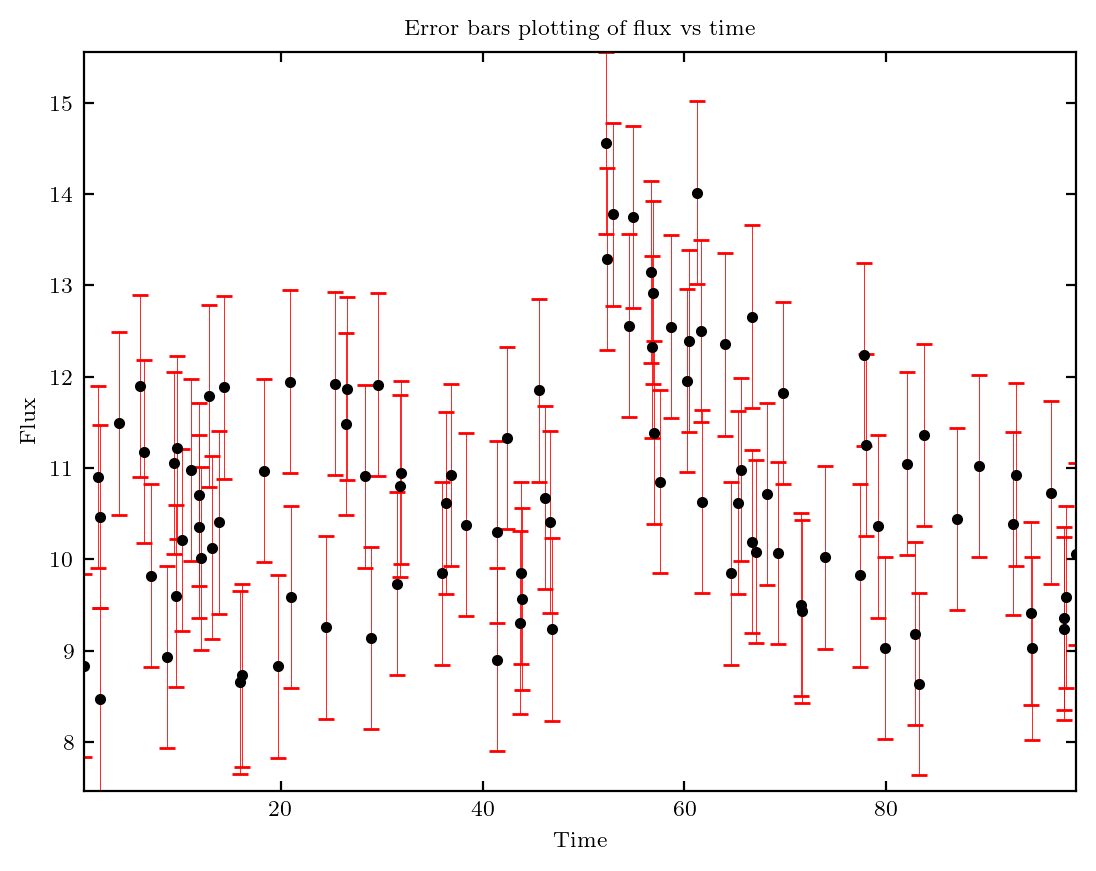

In [15]:
plt.errorbar(transient[:,0], transient[:,1], yerr = transient[:,2], fmt='.k', ecolor = 'red', elinewidth = 0.3)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Error bars plotting of flux vs time")

In [27]:
#our model is an initial noise for t < t0 and a sharp exponential tail which represents a "burst"
# b = background amplitude
# A = burst amplitude
# t0 = burst epoch
# alpha = tail-dying parameter
def model(t, theta):

    b, A, t0, alpha = theta
    
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

#let's compute the likelihood
def logLikelihood(theta, t, y, yerr):
    
    b, A, t0, ln_alpha = theta

    alpha = np.exp(ln_alpha)
    
    model_y = model(t, [b, A, t0, alpha])

    L = np.sum(np.log((1/yerr*(np.sqrt(2*np.pi))) * np.exp((-1*(y - model_y)**2/(2*yerr)))))

    return L

def log_prior(theta):
    b, A, t0, ln_alpha = theta
    
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < ln_alpha < 5:
        return 0.0 
    
    return -np.inf 

def log_posterior(theta, t, y, yerr):
    
    lp =  log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return logLikelihood(theta, t, y, yerr) + lp

In [35]:
#setup emcee
ndim = 4
nwalkers = 32  # number of MCMC walkers
nsteps = 50000 # number of MCMC steps to take **for each walker**
t = transient[:,0]
y = transient[:,1]
yerr = transient[:,2]

#generiamo i punti iniziali con un punto centrale + una deviazione randomica per i diversi walkers
initial_pos = [25, 20, 50, 0] + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, y, yerr))
sampler.run_mcmc(initial_pos, nsteps)

State([[ 9.96657159  5.05398326 49.52365419 -2.45081904]
 [10.27414489  5.85366133 48.12971013 -2.21699577]
 [10.22289058  4.59003202 49.86764995 -2.15816184]
 [10.2559717   6.8955813  49.23476241 -1.76314235]
 [10.35266095  3.9203435  50.06711564 -2.32146567]
 [10.31817641  4.86755038 49.6667381  -2.00357734]
 [10.25433711  6.91390756 48.26215398 -2.11636751]
 [10.3069443   7.10563517 47.65656155 -2.16377318]
 [10.13738716  4.34373488 49.05807063 -2.41216232]
 [10.24833043  5.12778203 48.13923205 -2.33796721]
 [10.16322456  6.45874554 47.37952541 -2.13823392]
 [10.36359974  3.14135846 51.86312424 -2.39771185]
 [10.25402312  7.40297482 48.46626825 -1.89066135]
 [10.42501408  4.68204071 50.2093717  -2.05528673]
 [10.20658644  6.53421924 47.80765378 -2.25996036]
 [10.15093326  6.01496415 48.80665336 -2.14426536]
 [10.4248172   4.49382498 47.14925453 -2.2718897 ]
 [10.34697876  3.70547755 50.20665215 -2.28477382]
 [10.38184095  5.9230651  47.67479017 -2.14583979]
 [10.4491406   6.52132027

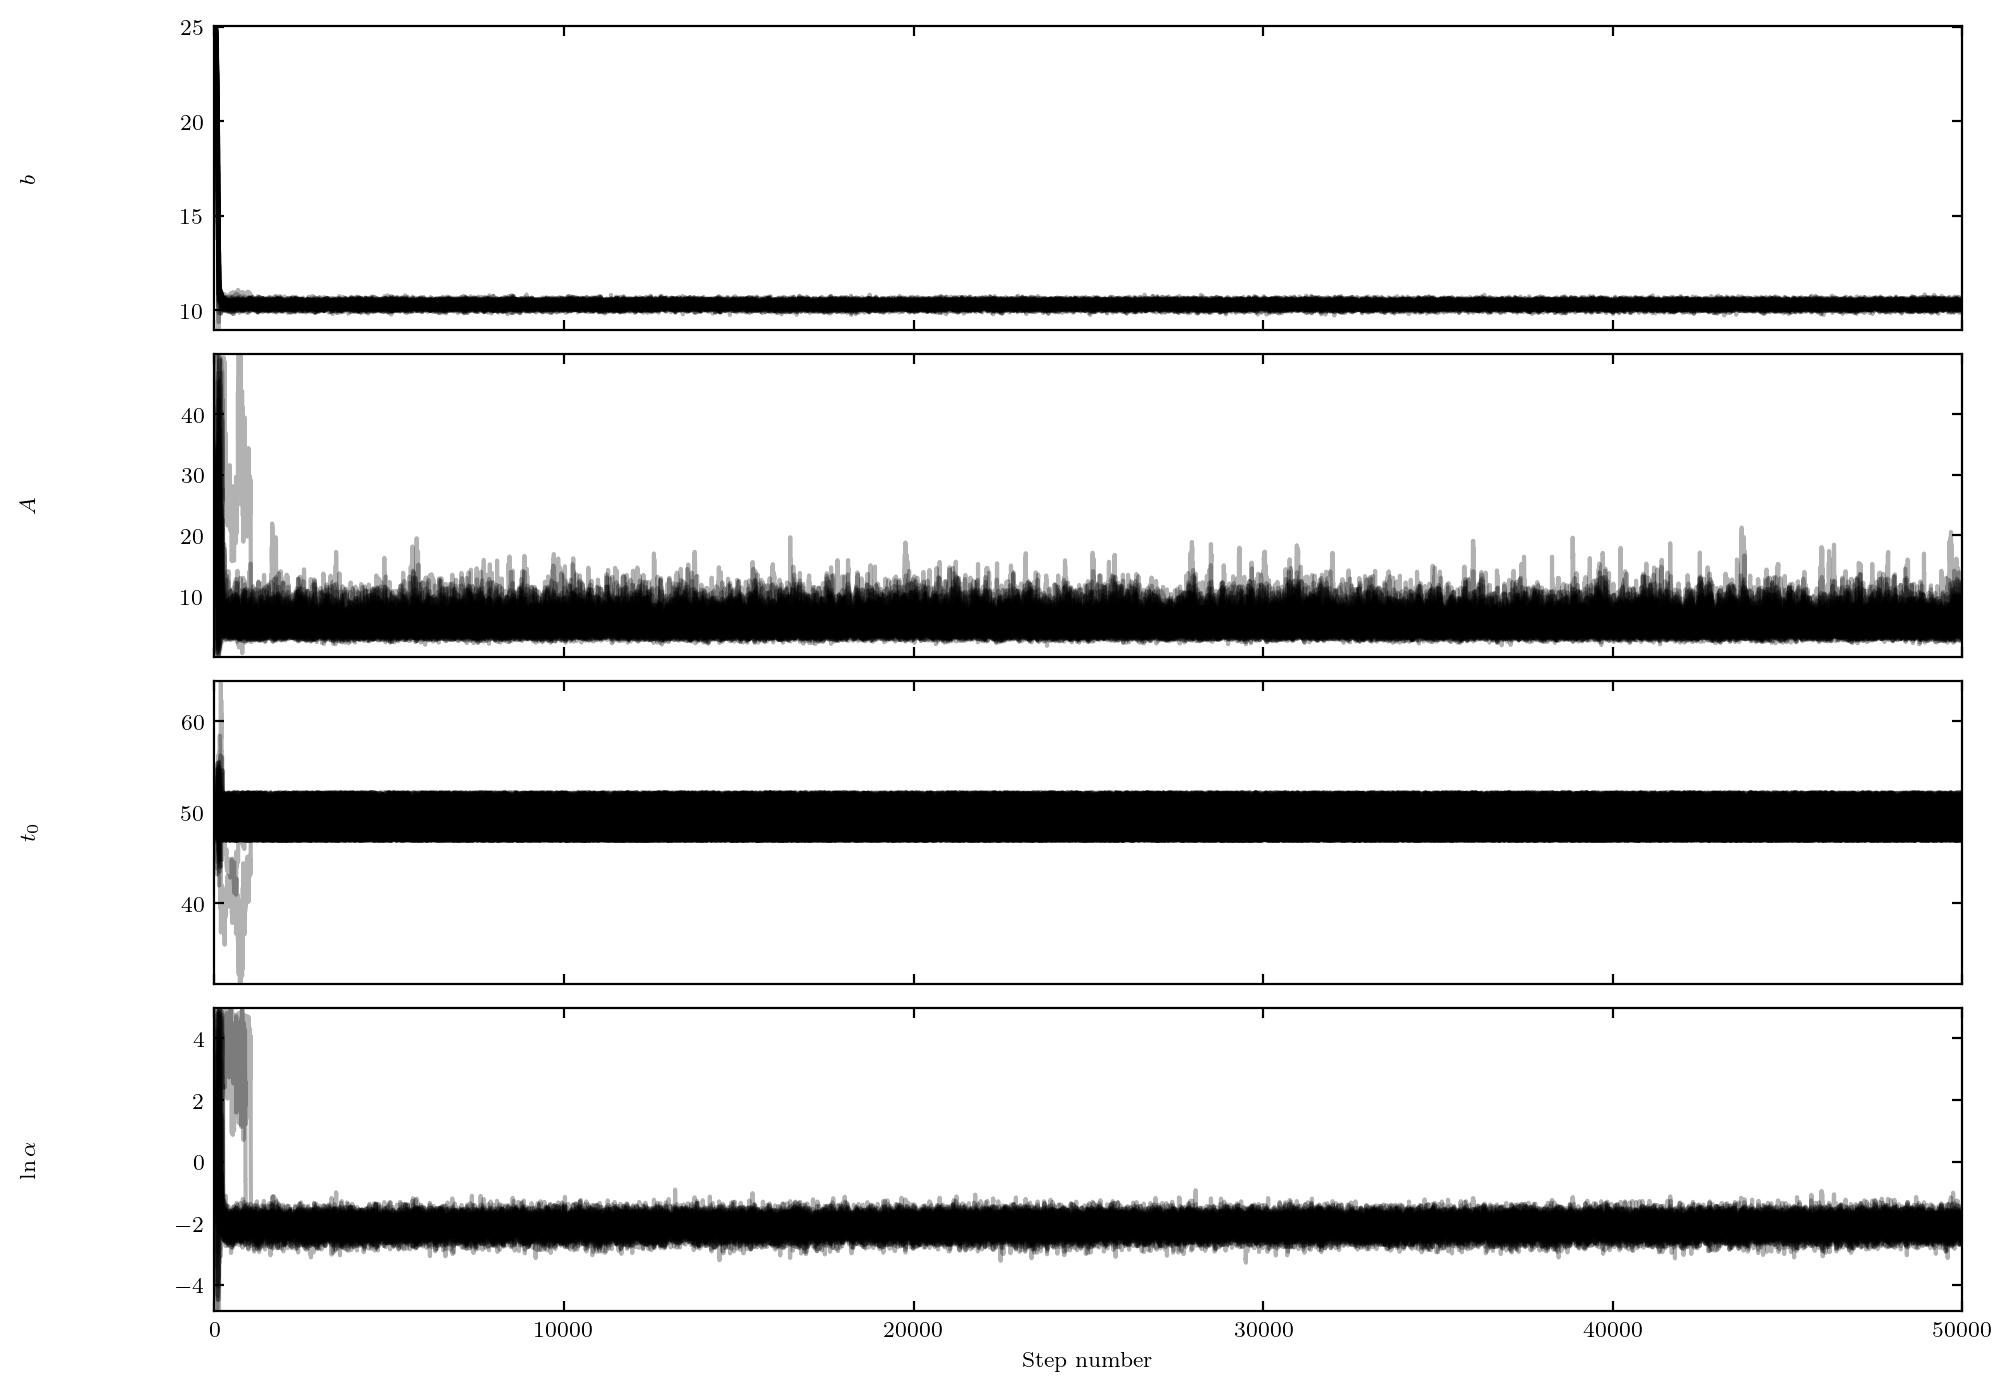

In [41]:
samples = sampler.get_chain()
labels = [r"$b$", r"$A$", r"$t_0$", r"$\ln\alpha$"]
ndim = len(labels)

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)

for i in range(ndim):
    ax = axes[i]
    # plotta i passi di ogni walker per il parametro i
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

In [53]:
burn_in = 5000
emcee_trace  = sampler.chain[:, burn_in:, :].reshape(-1, ndim)

tau = sampler.get_autocorr_time()
print(f"Tempi di autocorrelazione: {tau}")
thin = int(np.max(tau)+1)
flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

Tempi di autocorrelazione: [115.15827751 128.98765279  84.68570854 145.85930364]


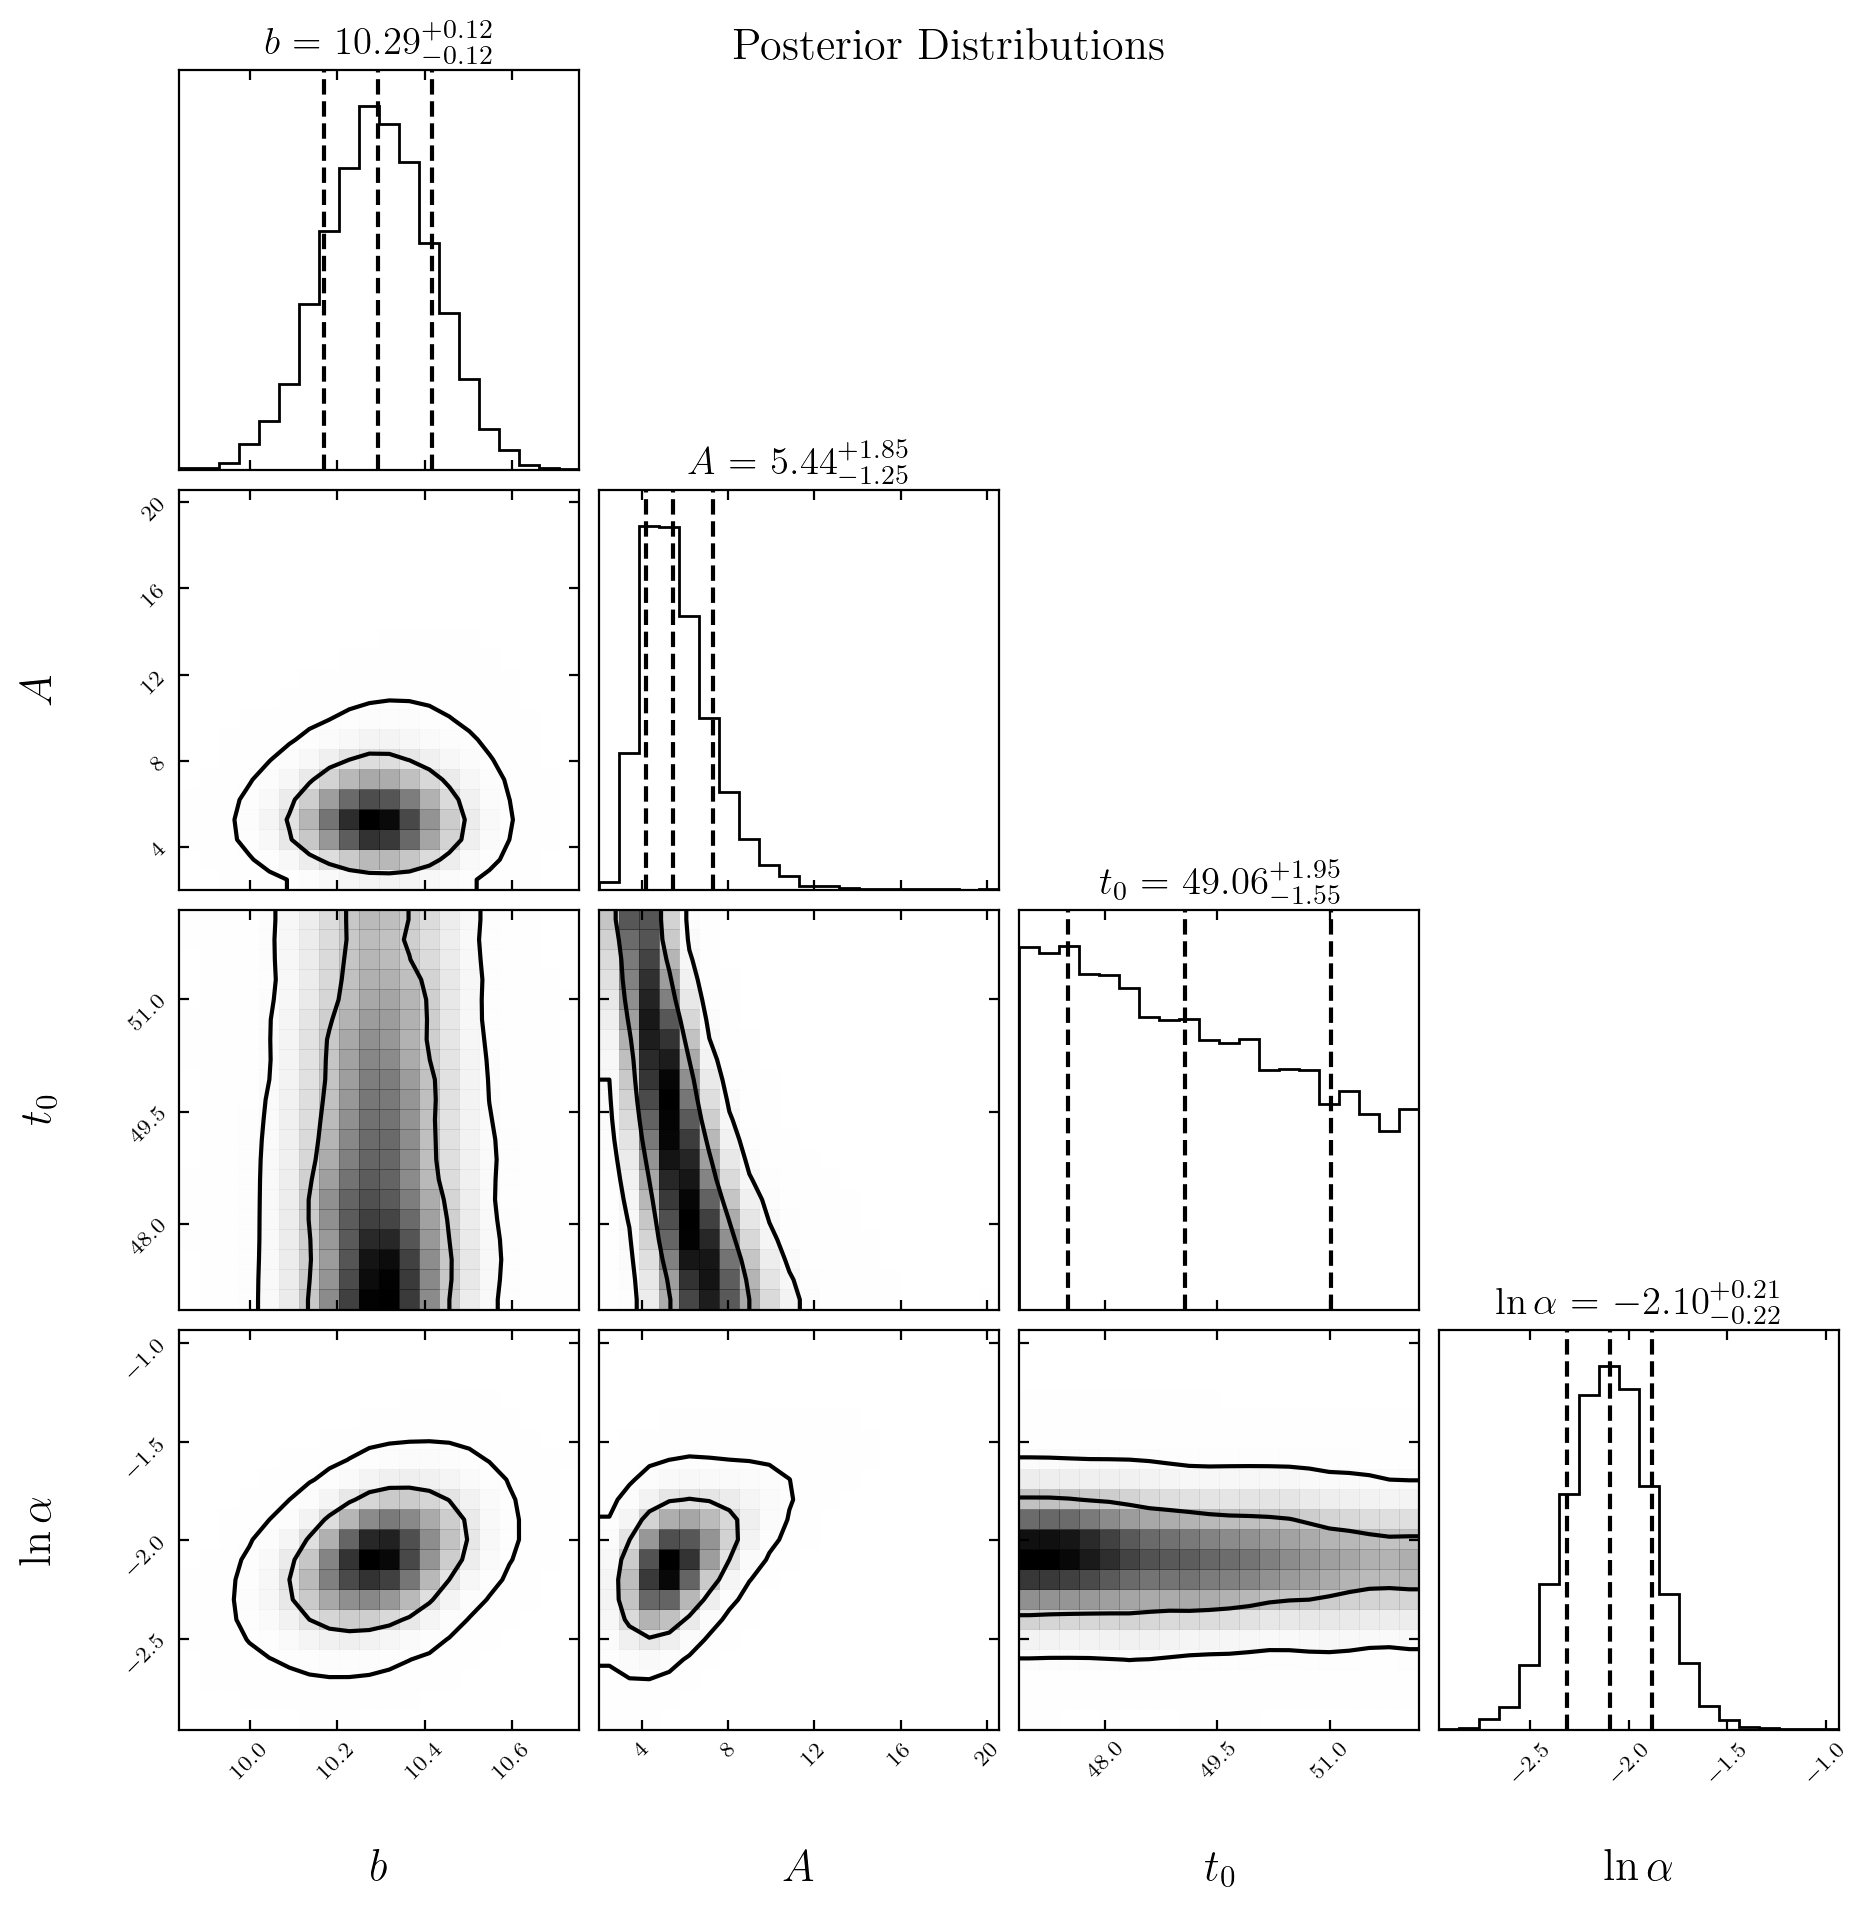

In [61]:
labels = [r"$b$", r"$A$", r"$t_0$", r"$\ln\alpha$"]

#Corner plot
fig = corner.corner(
    flat_samples, 
    labels=labels,
    # Mostriamo i quantili per la mediana e l'intervallo al 68% (1-sigma)
    quantiles=[0.16, 0.5, 0.84], 
    # Impostiamo i livelli per i contorni al 68% e 95%
    levels=(0.68, 0.95),
    show_titles=True, 
    # --- DIMENSIONI TITOLI (quelli sopra gli istogrammi) ---
    title_kwargs={"fontsize": 14}, 
    # --- DIMENSIONI ETICHETTE ASSI ($b$, $A$, ecc.) ---
    label_kwargs={"fontsize": 16},
    smooth=1.0,          
    plot_datapoints=False
)
fig.suptitle("Posterior Distributions", fontsize=16)
plt.savefig("L11_posterior_distributions")
plt.show()


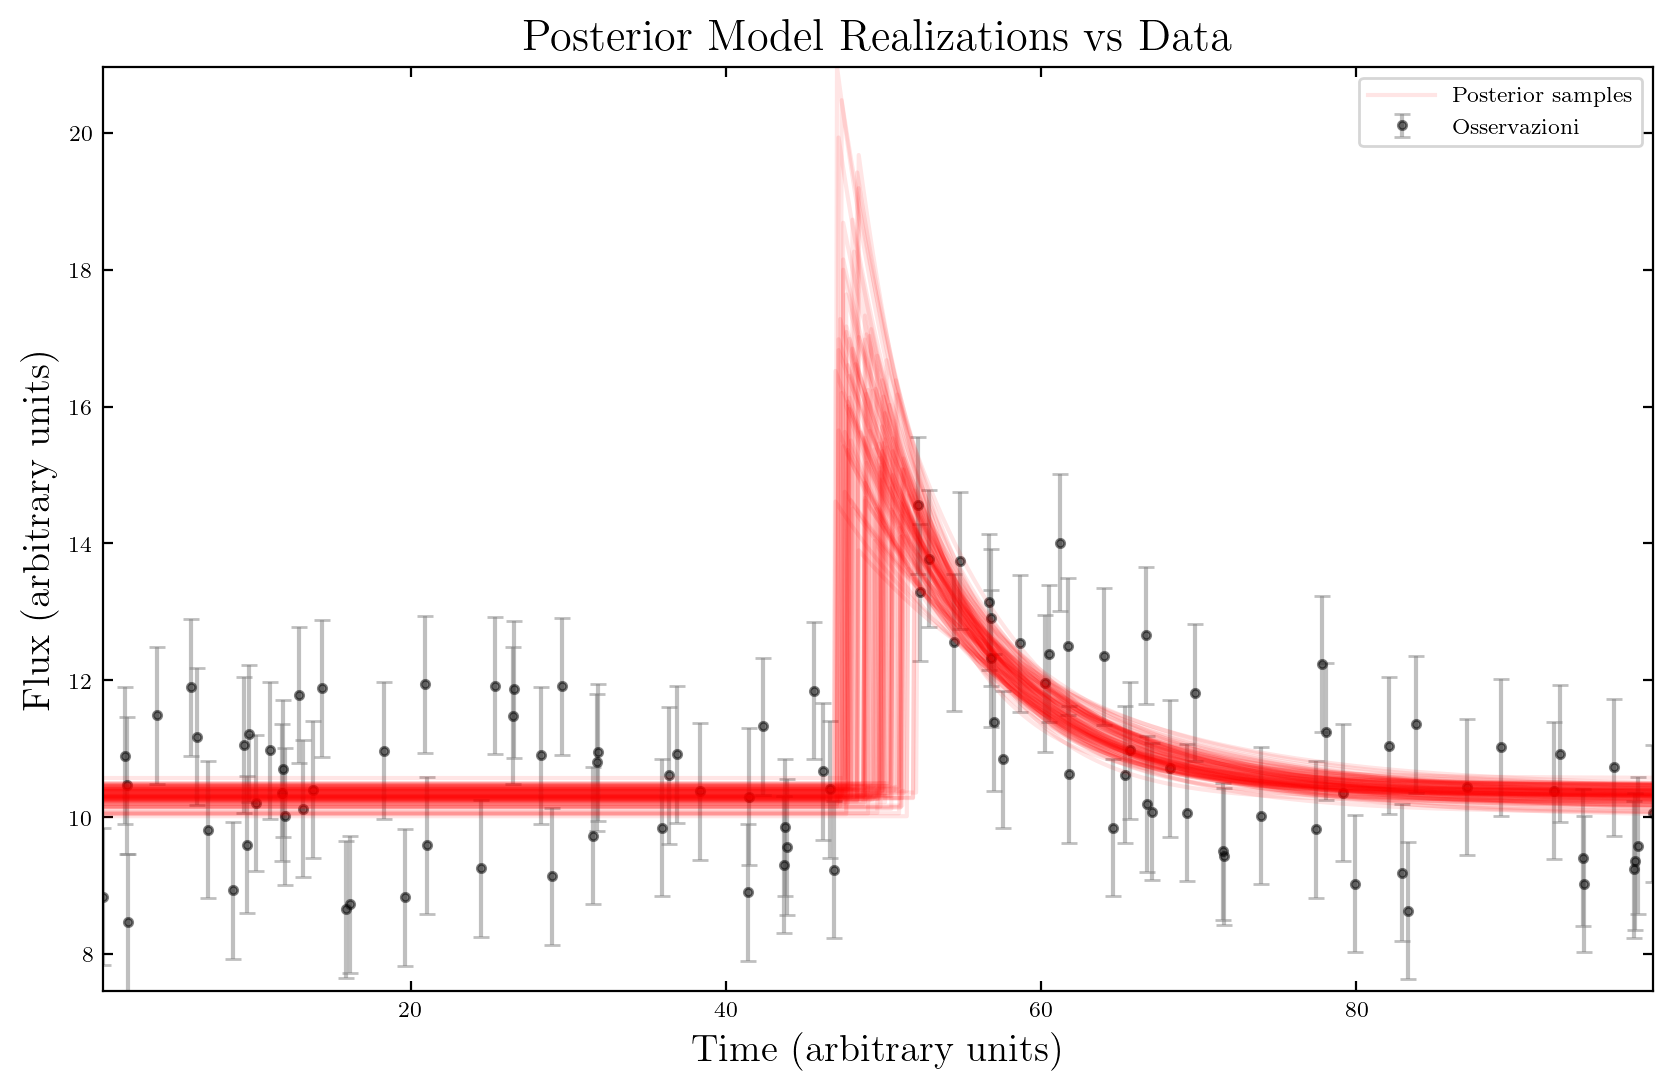

In [67]:
# Creiamo un array di tempo più denso per avere curve fluide nel plot
t_fine = np.linspace(t.min(), t.max(), 1000)

plt.figure(figsize=(10, 6))

# 1. Plottiamo i dati originali con barre d'errore
# Usiamo un'alfa bassa per i dati così le curve del modello risaltano
plt.errorbar(t, y, yerr=yerr, fmt='.k', ecolor='gray', 
             alpha=0.5, label='Osservazioni', zorder=1)

# 2. Scegliamo 100 indici casuali dalla catena flattata
inds = np.random.randint(len(flat_samples), size=100)

# 3. Ciclo per plottare le 100 realizzazioni del modello
for i, ind in enumerate(inds):
    # Estraiamo i parametri per il campione i-esimo
    # Ricorda l'ordine: b, A, t0, ln_alpha
    params = flat_samples[ind]
    b_i, A_i, t0_i, ln_alpha_i = params
    
    # Trasformiamo ln_alpha nel valore lineare per il modello
    alpha_i = np.exp(ln_alpha_i)
    
    # Calcoliamo il modello
    y_model = model(t_fine, [b_i, A_i, t0_i, alpha_i])
    
    # Plottiamo con alta trasparenza (alpha=0.1)
    # Aggiungiamo la label solo per la prima linea per evitare duplicati in legenda
    label = "Posterior samples" if i == 0 else ""
    plt.plot(t_fine, y_model, color='red', alpha=0.1, zorder=2, label=label)

plt.xlabel("Time (arbitrary units)", fontsize=14)
plt.ylabel("Flux (arbitrary units)", fontsize=14)
plt.title("Posterior Model Realizations vs Data", fontsize=16)
plt.legend()
plt.show()

In [68]:
# Definiamo i nomi dei parametri per il print finale
param_names = ["b", "A", "t0", "ln_alpha"]

print("Risultati della Bayesian Analysis (90% Credible Region):")
print("-" * 50)

for i in range(ndim):
    # Calcoliamo i percentili 5, 50, 95
    p5, p50, p95 = np.percentile(flat_samples[:, i], [5, 50, 95])
    
    # Calcoliamo gli scostamenti dalla mediana
    upper_error = p95 - p50
    lower_error = p50 - p5
    
    # Stampiamo nel formato richiesto: X +Y -Z
    # Usiamo .3f per mantenere la precisione mostrata nel corner plot
    print(f"{param_names[i]} = {p50:.3f}^{{+{upper_error:.3f}}}_{{-{lower_error:.3f}}}")

Risultati della Bayesian Analysis (90% Credible Region):
--------------------------------------------------
b = 10.293^{+0.200}_{-0.201}
A = 5.437^{+3.458}_{-1.804}
t0 = 49.064^{+2.747}_{-1.995}
ln_alpha = -2.097^{+0.359}_{-0.356}
